## LINEAR REGRESSIN, RANDOM FOREST AND TRUNED RANDOM FOREST

In [15]:
# California Housing Dataset
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [16]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
df.shape

(20640, 9)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [23]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [25]:
#Missing Value Check
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Price,0,0.0


In [30]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (16512, 8)
Testing data : (4128, 8)


In [80]:
#Linear Regression Model Train
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit( X_train, y_train )
print("LinearRegression model Trained Successfully!")

LinearRegression model Trained Successfully!


In [34]:
#Prediction
y_pred = model.predict(X_test)
print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [36]:
#ACTUL VAS PREDICT PRICE COMPARISON
comparison = pd.DataFrame({'Actual Price': y_test.values,
                          'Predicted Price': y_pred})
comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [37]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.5332001304956558
MSE : 0.5558915986952438
RMSE: 0.745581383012776
R² Score: 0.5757877060324512


In [81]:
#Feature Coefficient Analysis
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [82]:
#Model Coefficients and Intercept
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept: -37.023277706064235
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337


In [40]:
print("Linear Regression Equation:")

equation = f"Price = {model.intercept_:.4f}"

for feature, coef in zip(X.columns, model.coef_):
    equation += f" + ({coef:.4f} × {feature})"

print(equation)

Linear Regression Equation:
Price = -37.0233 + (0.4487 × MedInc) + (0.0097 × HouseAge) + (-0.1233 × AveRooms) + (0.7831 × AveBedrms) + (-0.0000 × Population) + (-0.0035 × AveOccup) + (-0.4198 × Latitude) + (-0.4337 × Longitude)


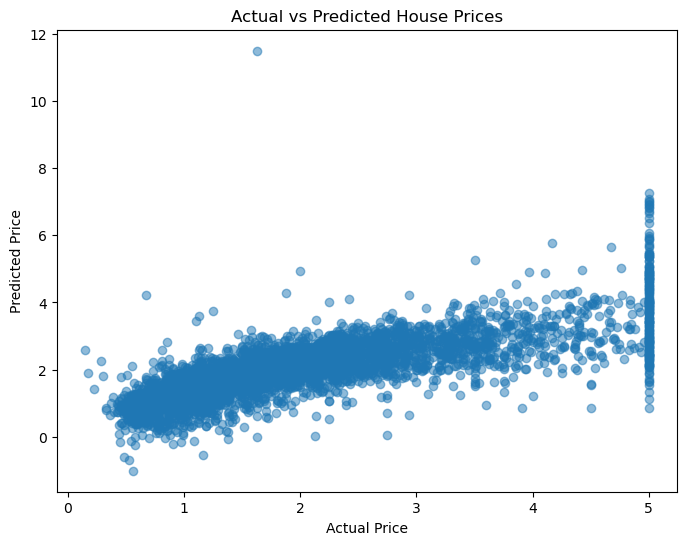

In [41]:
#Actual Vass Predicted Visualization
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [42]:
#Residual Analysis
residuals = y_test - y_pred

print(residuals.head())

20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
Name: Price, dtype: float64


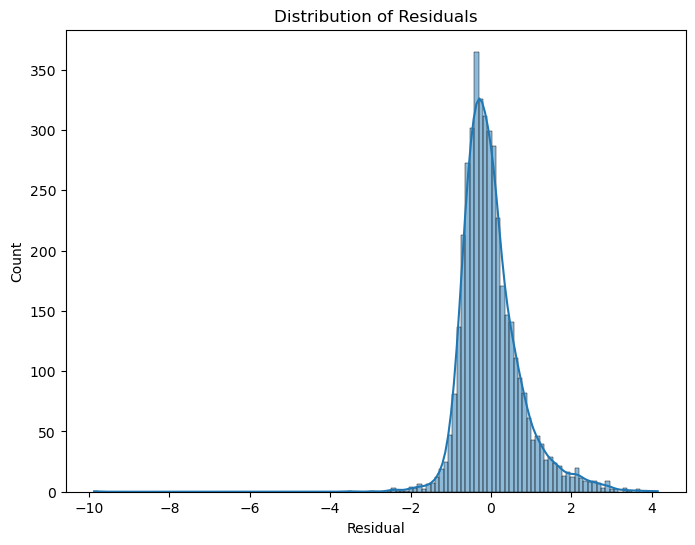

In [83]:
#residual distribution vizualisassin
plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

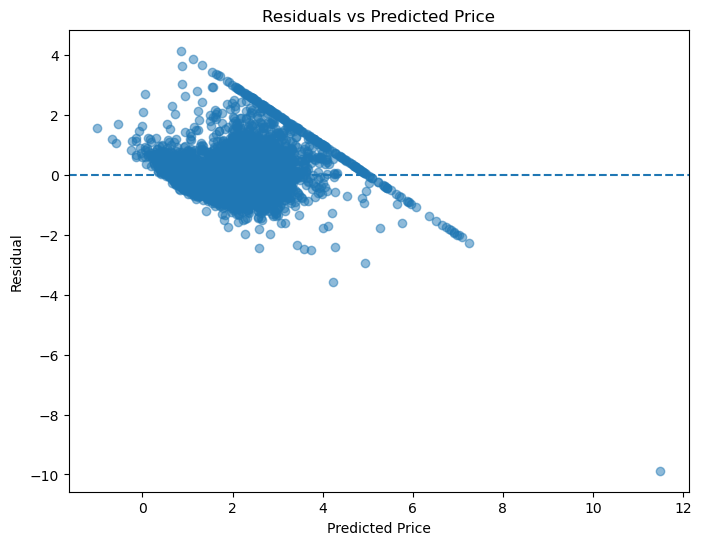

In [84]:
#Residual vs Predicted Plot
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price")

plt.show()

In [85]:
#Residual Statistics
print("Mean Residual:", residuals.mean())
print("Std Residual:", residuals.std())
print("Min Residual:", residuals.min())
print("Max Residual:", residuals.max())

Mean Residual: 0.0034792979037544924
Std Residual: 0.7456635880479102
Min Residual: -9.875331025900834
Max Residual: 4.148388195363491


In [46]:
absolute_errors = np.abs(residuals)

print("Mean Absolute Error:", absolute_errors.mean())
print("Maximum Absolute Error:", absolute_errors.max())

Mean Absolute Error: 0.5332001304956558
Maximum Absolute Error: 9.875331025900834


In [48]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [50]:
#Scaled Data with Linear Regression Train
scaled_model = LinearRegression()

scaled_model.fit(X_train_scaled, y_train)

print("Scaled Linear Regression Model Trained Successfully!")

Scaled Linear Regression Model Trained Successfully!


In [52]:
#PREDICTION
y_pred_scaled = scaled_model.predict(X_test_scaled)

print(y_pred_scaled[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [53]:
scaled_model = LinearRegression()

scaled_model.fit(X_train_scaled, y_train)

print("Scaled Linear Regression Model Trained Successfully!")

Scaled Linear Regression Model Trained Successfully!


In [54]:
y_pred_scaled = scaled_model.predict(X_test_scaled)

print(y_pred_scaled[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [56]:
#Scaled Model Evaluation
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("MAE :", mae_scaled)
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("R² Score:", r2_scaled)

MAE : 0.5332001304956566
MSE : 0.5558915986952443
RMSE: 0.7455813830127763
R² Score: 0.5757877060324508


In [57]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [58]:
#Random Forest Prediction
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[0.5095    0.74161   4.9232571 2.52961   2.27369   1.64692   2.37605
 1.66932   2.7729706 4.9134589]


In [60]:
#ACTUAL VAS PREDICT PRICE
rf_comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_rf
})

rf_comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,0.509500
1,0.45800,0.741610
2,5.00001,4.923257
3,2.18600,2.529610
4,2.78000,2.273690
5,1.58700,1.646920
6,1.98200,2.376050
7,1.57500,1.669320
8,3.40000,2.772971
9,4.46600,4.913459


In [61]:
#Random Forest Model Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE : 0.3275425684593025
MSE : 0.2553684927247781
RMSE: 0.5053399773665033
R² Score: 0.8051230593157366


In [79]:
#COPARISON OF LINEARREGRESSIN VAS RANDOM FORESRT REGRESSIN
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R² Score': [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.327543,0.505340,0.805123


In [64]:
#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,MedInc,0.524871
5,AveOccup,0.138443
6,Latitude,0.088936
7,Longitude,0.088629
1,HouseAge,0.054593
2,AveRooms,0.044272
4,Population,0.030650
3,AveBedrms,0.029606


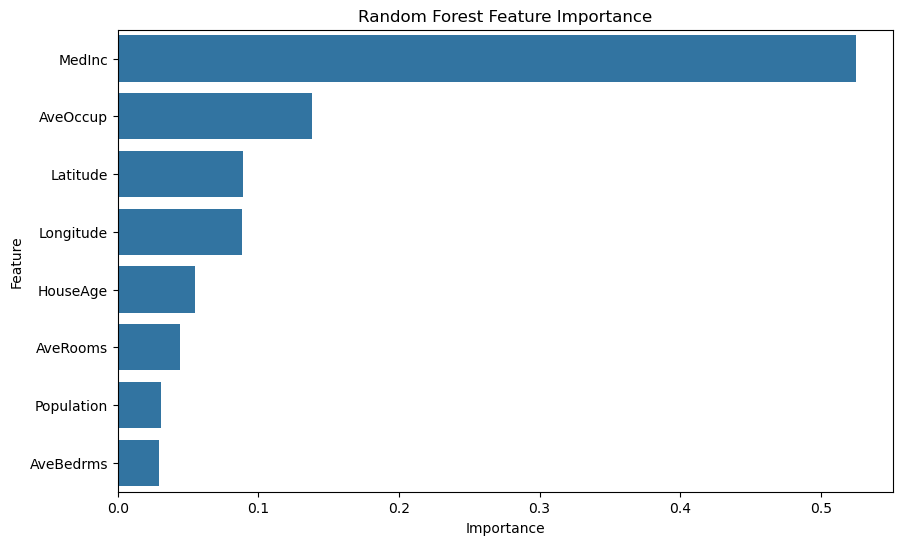

In [65]:
#visualization:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [66]:
#Random Forest Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R² Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV R² Score:
0.8013884636036114


In [67]:
#Tuned Model
best_rf_model = grid_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

In [68]:
#Test Evaluation
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("-------------------")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R² Score:", r2_tuned)

Tuned Random Forest
-------------------
MAE : 0.3268118504360468
MSE : 0.2539759249192041
RMSE: 0.5039602414072009
R² Score: 0.8061857564039718


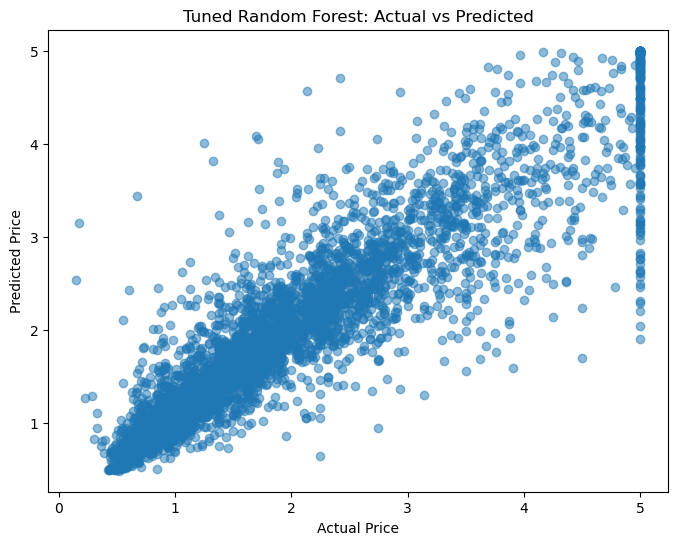

In [69]:
#VIZUALISASSION
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_tuned, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Tuned Random Forest: Actual vs Predicted")

plt.show()

In [70]:
# Step 22: Tuned Random Forest Feature Importance

tuned_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
})

tuned_feature_importance = tuned_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

tuned_feature_importance

,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088647
7,Longitude,0.088307
1,HouseAge,0.054355
2,AveRooms,0.044449
4,Population,0.030693
3,AveBedrms,0.029608


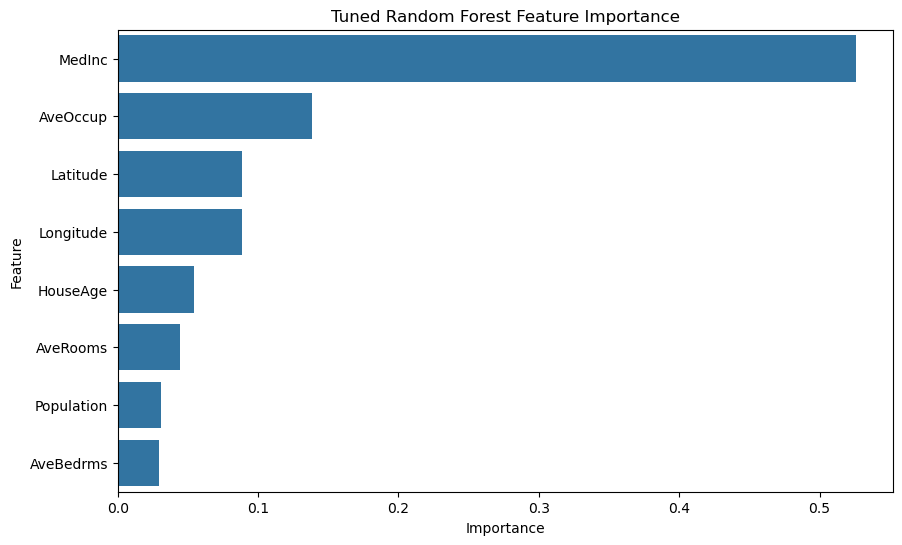

In [71]:
# Step 23: Tuned Random Forest Feature Importance Visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=tuned_feature_importance
)

plt.title("Tuned Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

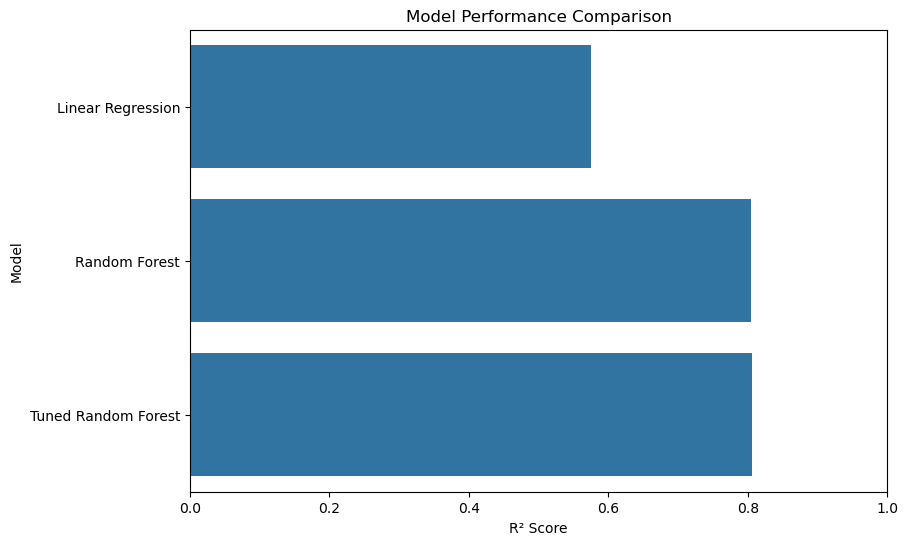

In [72]:
# Step 24: Model Performance Comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'R2 Score': [
        r2,
        r2_rf,
        r2_tuned
    ]
})

plt.figure(figsize=(9, 6))

sns.barplot(
    x='R2 Score',
    y='Model',
    data=model_comparison
)

plt.title("Model Performance Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(0, 1)
plt.show()

In [73]:
# Step 25: Final Model Performance Summary

final_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'MAE': [
        mae,
        mae_rf,
        mae_tuned
    ],
    'RMSE': [
        rmse,
        rmse_rf,
        rmse_tuned
    ],
    'R² Score': [
        r2,
        r2_rf,
        r2_tuned
    ]
})

final_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.327543,0.505340,0.805123
2,Tuned Random Forest,0.326812,0.503960,0.806186


In [74]:
# Step 26: Select the Best Model

best_model_row = final_comparison.loc[
    final_comparison['R² Score'].idxmax()
]

print("Best Model:", best_model_row['Model'])
print("MAE:", best_model_row['MAE'])
print("RMSE:", best_model_row['RMSE'])
print("R² Score:", best_model_row['R² Score'])

Best Model: Tuned Random Forest
MAE: 0.3268118504360468
RMSE: 0.5039602414072009
R² Score: 0.8061857564039718


In [75]:
# Step 27: Predict a New House Price

new_house = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [20],
    'AveRooms': [6.0],
    'AveBedrms': [1.0],
    'Population': [1000],
    'AveOccup': [3.0],
    'Latitude': [34.0],
    'Longitude': [-118.0]
})

predicted_price = best_rf_model.predict(new_house)

print("Predicted House Price:")
print(f"${predicted_price[0] * 100000:,.2f}")

Predicted House Price:
$233,733.50


In [76]:
# Step 28: Save the Final Model

import joblib

joblib.dump(best_rf_model, 'house_price_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [77]:
# Step 29: Load the Saved Model

loaded_model = joblib.load('house_price_model.pkl')

# Test prediction
loaded_prediction = loaded_model.predict(new_house)

print("Loaded Model Prediction:")
print(f"${loaded_prediction[0] * 100000:,.2f}")

Loaded Model Prediction:
$233,733.50


In [78]:
# Step 30: Final Project Summary

print("========== HOUSE PRICE PREDICTION PROJECT ==========")
print()

print("Best Model        :", best_model_row['Model'])
print("MAE               :", round(best_model_row['MAE'], 4))
print("RMSE              :", round(best_model_row['RMSE'], 4))
print("R² Score          :", round(best_model_row['R² Score'], 4))

print()
print("R² Percentage     :", round(best_model_row['R² Score'] * 100, 2), "%")
print()

print("Top 3 Important Features:")
print(tuned_feature_importance.head(3))

========== HOUSE PRICE PREDICTION PROJECT ==========

Best Model        : Tuned Random Forest
MAE               : 0.3268
RMSE              : 0.504
R² Score          : 0.8062

R² Percentage     : 80.62 %

Top 3 Important Features:
    Feature  Importance
0    MedInc    0.525886
5  AveOccup    0.138055
6  Latitude    0.088647


# House Price Prediction Machine Learning Project 

Final Result
Best Model: Tuned Random Forest
R² Score: 0.8062 →  80.62%
MAE: 0.3268 →  $32,681
RMSE: 0.5040 →  $50,396
Most Important Feature: MedInc → 52.59%

we complete project
Data Loading → DataFrame → Missing Value Check → Train/Test Split → Linear Regression → Prediction → Evaluation 
→ Feature Analysis → Random Forest → Hyperparameter Tuning → Final Model → Prediction → Model Saving & Loading → Final Evaluation

It's a  complete end-to-end Machine Learning project.

# House Price Prediction using Machine Learning

## Project Objective

The objective of this project is to predict house prices using machine learning
techniques based on various housing and demographic features.

### Models Used
- Linear Regression
- Random Forest Regression
- Tuned Random Forest Regression

### Best Model
Tuned Random Forest Regression

### Best R² Score
80.62%

## 1. Dataset Overview

The California Housing dataset is used for this project.

The dataset contains information about housing districts in California.
It includes demographic, housing, and geographical features that can be
used to predict the median house value.

### Key Features

- **MedInc** — Median income
- **HouseAge** — Median house age
- **AveRooms** — Average number of rooms
- **AveBedrms** — Average number of bedrooms
- **Population** — District population
- **AveOccup** — Average household occupancy
- **Latitude** — Geographic latitude
- **Longitude** — Geographic longitude

### Target Variable

- **Price** — Median house value

In [86]:
# Step 33: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [87]:
# Load California Housing Dataset

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['Price'] = housing.target

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 20640
Columns: 9


In [88]:
#  Initial Dataset Inspection

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Shape:
(20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [89]:
#  Missing Value Analysis

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

missing_report

,Missing Values,Percentage (%)
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Price,0,0.0


In [90]:
# Descriptive Statistics

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


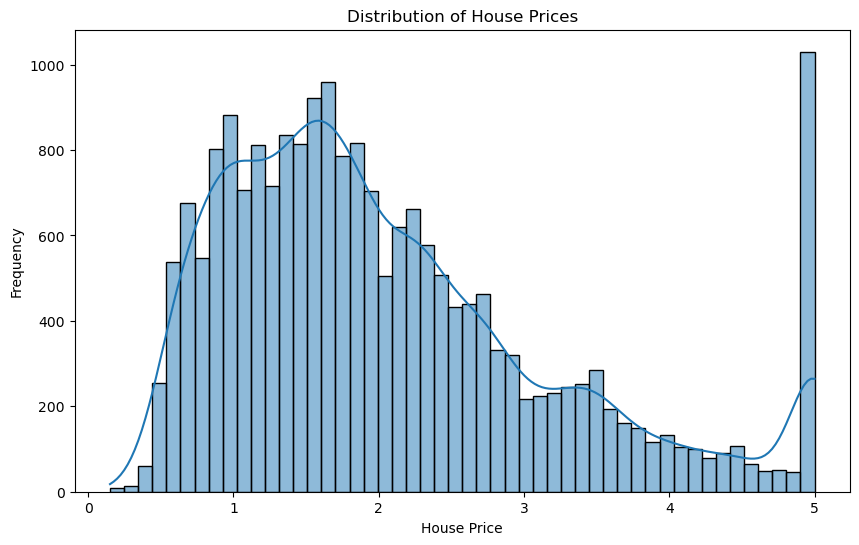

In [91]:
#  Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(df['Price'], bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

In [92]:
#  Correlation Analysis

correlation = df.corr(numeric_only=True)

price_correlation = correlation['Price'].sort_values(
    ascending=False
)

price_correlation

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

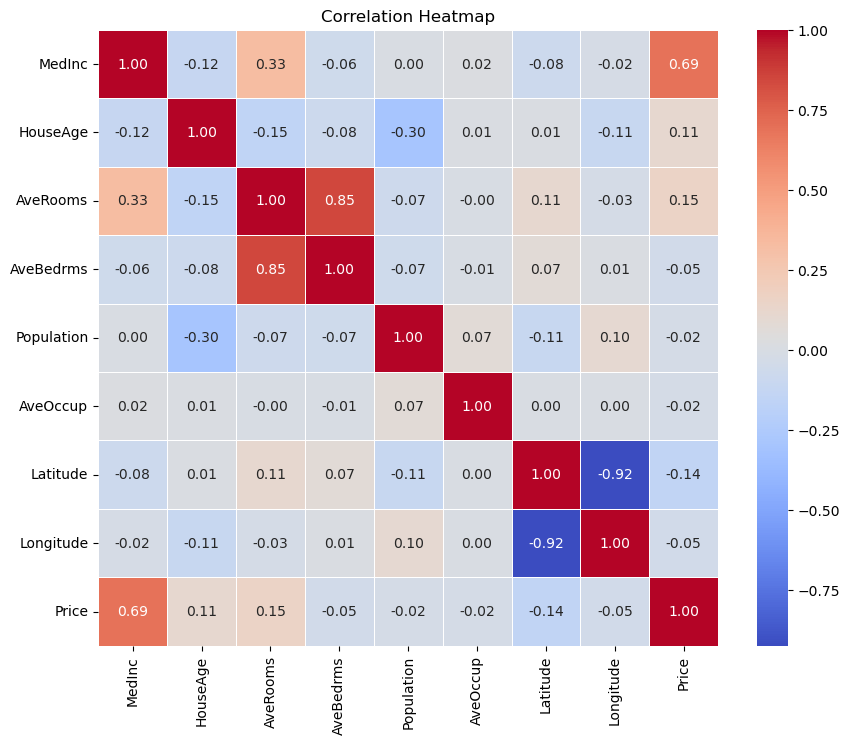

In [93]:
#  Correlation Heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

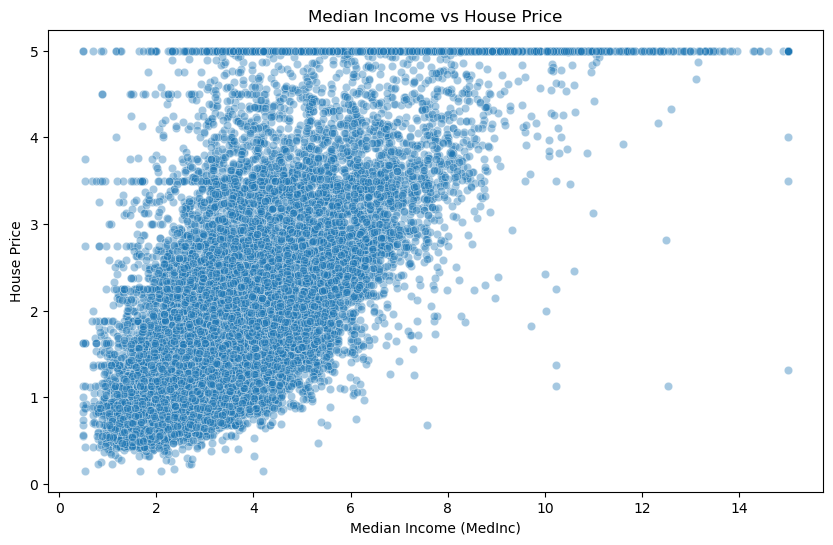

In [94]:
#  MedInc vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='MedInc',
    y='Price',
    data=df,
    alpha=0.4
)

plt.title("Median Income vs House Price")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("House Price")

plt.show()

In [95]:
#  Prepare Features and Target#Machine learning

X = df.drop('Price', axis=1)
y = df['Price']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nFeature Names:")
print(X.columns.tolist())

Features (X): (20640, 8)
Target (y): (20640,)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [96]:
#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (16512, 8)
Testing Data : (4128, 8)


In [97]:
#  Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [98]:
#  Linear Regression Prediction

y_pred_linear = linear_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_linear[:10])

First 10 Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


# Final Project Report

## 1. Project Objective

The objective of this project is to develop a machine learning model
that can predict house prices based on housing, demographic, and
geographical features.

## 2. Dataset

The California Housing dataset was used for this project.

The dataset contains 20,640 records and 8 input features:

- MedInc
- HouseAge
- AveRooms
- AveBedrms
- Population
- AveOccup
- Latitude
- Longitude

The target variable is Price.

## 3. Data Analysis

The dataset was analyzed for:

- Missing values
- Descriptive statistics
- Target variable distribution
- Feature correlation
- Feature vs target relationships

No missing values were found in the dataset.

## 4. Machine Learning Models

Three models were evaluated:

1. Linear Regression
2. Random Forest Regression
3. Tuned Random Forest Regression

## 5. Model Performance

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 0.5332 | 0.7456 | 0.5758 |
| Random Forest | 0.3275 | 0.5053 | 0.8051 |
| Tuned Random Forest | 0.3268 | 0.5040 | 0.8062 |

## 6. Best Model

The Tuned Random Forest Regression model achieved the best performance.

- R² Score: 0.8062
- MAE: 0.3268
- RMSE: 0.5040

The model explains approximately 80.62% of the variation in house prices.

## 7. Feature Importance

The most important features identified by the Tuned Random Forest model were:

1. MedInc — 52.59%
2. AveOccup — 13.81%
3. Latitude — 8.86%
4. Longitude — 8.83%

MedInc was the most influential feature in the model.

## 8. Conclusion

The analysis demonstrates that machine learning can effectively predict
house prices using housing, demographic, and geographical information.

Among the evaluated models, the Tuned Random Forest Regression model
performed the best and was selected as the final model.

The trained model was also saved and successfully loaded for future
predictions.

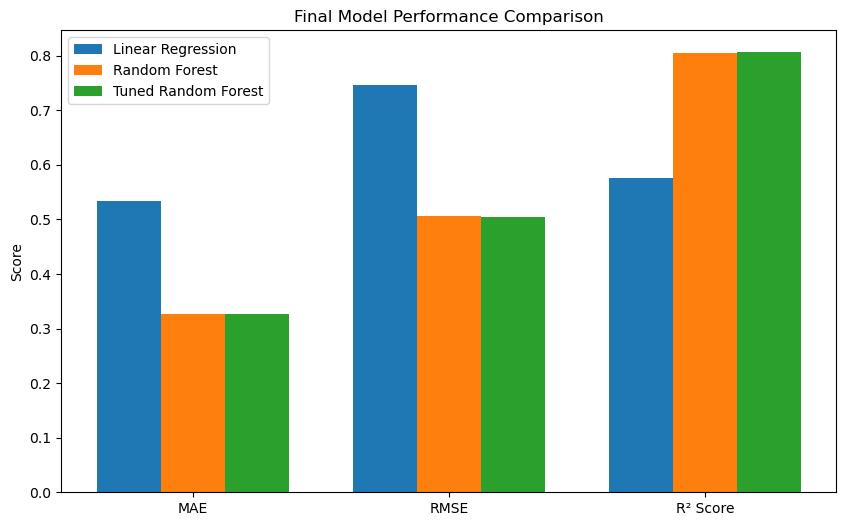

In [99]:
# Step 46: Final Model Performance Visualization

metrics = ['MAE', 'RMSE', 'R² Score']

linear_values = [mae, rmse, r2]
rf_values = [mae_rf, rmse_rf, r2_rf]
tuned_values = [mae_tuned, rmse_tuned, r2_tuned]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, linear_values, width, label='Linear Regression')
plt.bar(x, rf_values, width, label='Random Forest')
plt.bar(x + width, tuned_values, width, label='Tuned Random Forest')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Final Model Performance Comparison')
plt.legend()

plt.show()

# Key Insights

## Major Findings

- The Tuned Random Forest model achieved the highest R² Score of **80.62%**.
- Random Forest models performed significantly better than Linear Regression.
- **MedInc** was the most important feature, contributing approximately **52.59%** of total feature importance.
- **AveOccup** was the second most important feature with approximately **13.81%** importance.
- Geographic features (**Latitude** and **Longitude**) also had a meaningful impact on predictions.
- The final model achieved an MAE of approximately **0.327** and an RMSE of approximately **0.504**.

## Business Interpretation

The analysis indicates that household income, occupancy, and geographic
location are important factors for predicting median house values.

The Tuned Random Forest model can therefore be considered the most
effective model among the three evaluated approaches for this dataset.